In [6]:
import torch
import os
from pathlib import Path
from dotenv import load_dotenv

# Load environment variables from .env file
project_root = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
load_dotenv(dotenv_path=project_root / ".env", override=False)

# 1) Read concept bank path from .env (or construct from OUTPUT_DIR)
# Priority: CONCEPT_PATH > OUTPUT_DIR/concept/snmf/combined_concept_snmf_raw.pth
CONCEPT_PATH = os.getenv("CONCEPT_PATH")
OUTPUT_DIR = os.getenv("OUTPUT_DIR", str(project_root / "outputs/noidle"))

if CONCEPT_PATH:
    file_path = CONCEPT_PATH
else:
    # Default: OUTPUT_DIR/concept/snmf/combined_concept_snmf_raw.pth
    file_path = os.path.join(OUTPUT_DIR, "concept", "snmf", "combined_concept_snmf_raw.pth")

# 2) Read IMAGE_SIZE_WIDTH for visualization (default: 512)
IMAGE_SIZE_WIDTH = int(os.getenv("IMAGE_SIZE_WIDTH", "512"))

print(f"CONCEPT_PATH: {file_path}")
print(f"IMAGE_SIZE_WIDTH: {IMAGE_SIZE_WIDTH}")

concept_pth = Path(file_path)
assert concept_pth.exists(), f"Concept bank not found: {concept_pth}"
assert "raw" in concept_pth.stem.lower(), f"Expected a raw concept file, got: {concept_pth.name}"

data1 = torch.load(str(concept_pth), map_location="cpu")
print("Concept keys:", list(data1.keys()))

# Lightweight sanity print (avoid dumping huge arrays)
for k in ["concepts", "activations", "text_grounding", "image_grounding_paths", "image_grounding_bboxes", "image_grounding_predictions"]:
    if k not in data1:
        continue
    v = data1[k]
    if isinstance(v, torch.Tensor):
        print(f"{k}: tensor shape={tuple(v.shape)} dtype={v.dtype}")
    else:
        try:
            print(f"{k}: type={type(v).__name__} len={len(v)}")
        except Exception:
            print(f"{k}: type={type(v).__name__}")

# Peek at one concept's metadata (if present)
idx0 = 0
if isinstance(data1.get("text_grounding"), (list, tuple)) and len(data1["text_grounding"]) > 0:
    print("text_grounding[0] =", data1["text_grounding"][idx0])
if isinstance(data1.get("image_grounding_paths"), (list, tuple)) and len(data1["image_grounding_paths"]) > 0:
    print("image_grounding_paths[0] =", data1["image_grounding_paths"][idx0])
if isinstance(data1.get("image_grounding_bboxes"), (list, tuple)) and len(data1["image_grounding_bboxes"]) > 0:
    print("image_grounding_bboxes[0] =", data1["image_grounding_bboxes"][idx0])

CONCEPT_PATH: /mnt/abka03/Projects/xl-vlm-api/xl-vlms/outputs/noidle/concept/snmf/combined_concept_snmf_raw.pth
IMAGE_SIZE_WIDTH: 512
Concept keys: ['concepts', 'activations', 'decomposition_method', 'text_grounding', 'image_grounding_paths', 'image_grounding_bboxes', 'analysis_model', 'image_grounding_predictions']
concepts: tensor shape=(1, 2048) dtype=torch.float32
activations: type=list len=1
text_grounding: type=list len=1
image_grounding_paths: type=list len=1
image_grounding_bboxes: type=list len=1
image_grounding_predictions: type=list len=1
text_grounding[0] = ['sky']
image_grounding_paths[0] = ['/mnt/abka03/xlvlm_data/noidle/train/summit/20230825_105559.jpg', '/mnt/abka03/xlvlm_data/noidle/train/have_fun/20240423_112455.jpg', '/mnt/abka03/xlvlm_data/noidle/train/mountain_view/20231218_124802.jpg', '/mnt/abka03/xlvlm_data/noidle/train/relax/20240422_085135.jpg', '/mnt/abka03/xlvlm_data/noidle/train/trail/20231208_111844.jpg']
image_grounding_bboxes[0] = [[61, 1, 261, 201], [69

In [11]:
from pathlib import Path
import os
from dotenv import load_dotenv

# 2) Inputs
# Single-image mode:
image_to_infer = "/mnt/abka03/Projects/xl-vlm-api/xl-vlms/data/val/cake/48396.jpg"

# Multi-image mode (uncomment and add more paths):
# images_to_infer = [
#     "/path/to/img1.jpg",
#     "/path/to/img2.jpg",
# ]

word_to_explain = "blue"

# Build a binary prompt. The explainer will also enforce a strict binary instruction.
prompt = f"Is there a '{word_to_explain}' in the image? Answer '{word_to_explain}' or 'no {word_to_explain}'."

# 3) Load config (prefer .env if present; otherwise defaults match api/main.py)
project_root = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
load_dotenv(dotenv_path=project_root / ".env", override=False)

VLM_MODEL = os.getenv("VLM_MODEL", "Qwen/Qwen2.5-VL-3B-Instruct")
LAYER_PATH = os.getenv("LAYER_PATH", "model.language_model.norm")

# Resolve images list + choose multibatch when multiple images are provided
if "images_to_infer" in globals() and images_to_infer is not None:
    images = list(images_to_infer)
else:
    images = [image_to_infer]

images = [str(p) for p in images]
use_multibatch = len(images) > 1
print("VLM_MODEL:", VLM_MODEL)
print("LAYER_PATH:", LAYER_PATH)
print("#images:", len(images), "multibatch:", use_multibatch)
print("prompt:", prompt)


VLM_MODEL: Qwen/Qwen2.5-VL-3B-Instruct
LAYER_PATH: model.language_model.norm
#images: 1 multibatch: False
prompt: Is there a 'blue' in the image? Answer 'blue' or 'no blue'.


In [12]:
# 3.5) Sanity import (no model load)
import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(project_root / "inference"))

from vlm_explainer_multibatch import VLMConceptExplainer
print("Imported VLMConceptExplainer:", VLMConceptExplainer)


Imported VLMConceptExplainer: <class 'vlm_explainer_multibatch.VLMConceptExplainer'>


In [13]:
# 4) Inference + hook + concept scoring
# This cell implements your comments:
# - apply hook at LAYER_PATH
# - extract residual/hidden embeddings for generated output tokens
# - compute cosine similarity to concept bank

import sys
from pathlib import Path

# Ensure we can import the multibatch explainer
project_root = Path.cwd().resolve().parent if Path.cwd().resolve().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(project_root / "inference"))

from vlm_explainer_multibatch import VLMConceptExplainer

# Use multibatch only when multiple images are given
batch_size = min(2, len(images)) if len(images) > 1 else 1

explainer = VLMConceptExplainer(
    model_name=VLM_MODEL,
    concept_path=str(concept_pth),
    layer_path=LAYER_PATH,
    prompt_mode="binary",
    prompt_label=word_to_explain,
    # keep raw concepts; cosine similarity is scale-invariant
    normalize_concepts=False,
    verbose=False,
    # helps align activations to generated tokens
    save_only_generated_tokens=True,
)

results = explainer.explain_with_concept(
    images=images,
    ground_truth_labels=[word_to_explain] * len(images),
    top_n=5,
    max_new_tokens=80,
    temperature=0.0,
    batch_size=batch_size,
)
explainer.close()

print("Got", len(results), "result(s)")
print("Example keys:", list(results[0].keys()))
print("Model output[0]:", results[0]["model_output"])
print("Top concepts (aggregate)[0]:")
for c in (results[0].get("top_concepts_over_sequence") or [])[:5]:
    print(" ", f"#{c['rank']} idx={c['concept_index']} sim={c['similarity']:.4f} text={c.get('text_grounding')}")


Loading checkpoint shards: 100%|██████████| 2/2 [00:01<00:00,  1.62it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


Got 1 result(s)
Example keys: ['image_path', 'ground_truth', 'model_output', 'generated_token_ids', 'per_token_concepts', 'top_concepts_over_sequence', 'hook_layer', 'model_name']
Model output[0]: Blue
Top concepts (aggregate)[0]:
  #1 idx=0 sim=0.0997 text=['sky']


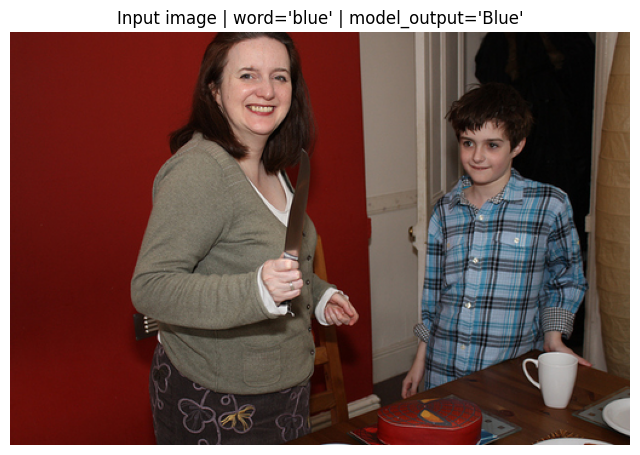

 I learnt how blue look like and what other objects it relates to, for example.
 (Image displayed at width=512px)


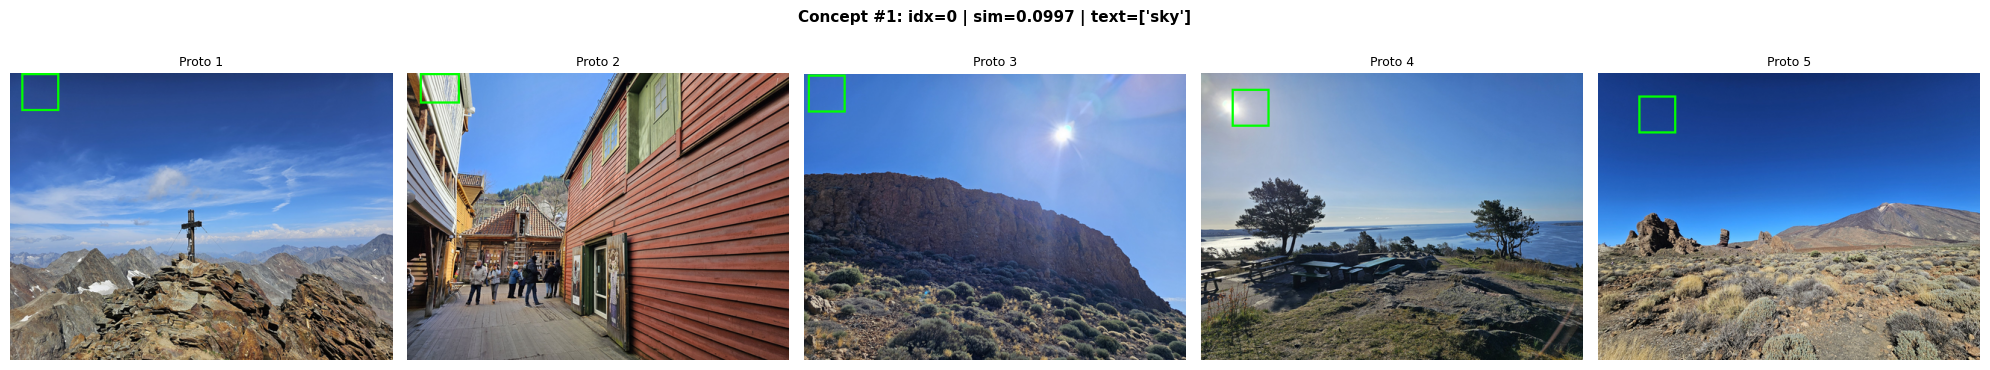


--- Summary ---
(All images resized to width=512px for visualization)
  #1 idx=0 sim=0.0997 text=['sky']


In [14]:
# 5) Prototype + bbox visualization for TOP 3 concepts, each with ALL 5 prototype images
#
# NOTE: image_grounding_bboxes[concept] is the bbox ON image_grounding_paths[concept],
#       not on the input image. So we draw the bbox on the prototype image.
#
# Uses IMAGE_SIZE_WIDTH from .env for consistent visualization sizing.

from PIL import Image, ImageDraw
import matplotlib.pyplot as plt


def _pick_first_bbox(b):
    """Return a single [x1,y1,x2,y2] bbox if present; else None."""
    if b is None:
        return None
    # common cases: [x1,y1,x2,y2] or [[...],[...]]
    if isinstance(b, (list, tuple)) and len(b) == 4 and all(isinstance(x, (int, float)) for x in b):
        return list(map(float, b))
    if isinstance(b, (list, tuple)) and len(b) > 0 and isinstance(b[0], (list, tuple)):
        return _pick_first_bbox(b[0])
    return None


def _resolve_proto_path(p: str) -> Path:
    pp = Path(str(p))
    if pp.exists():
        return pp
    # if stored relative, resolve relative to concept bank directory
    alt = concept_pth.parent / pp
    return alt


def resize_to_width(img: Image.Image, target_width: int) -> Image.Image:
    """Resize image to target width while maintaining aspect ratio."""
    if target_width <= 0:
        return img
    w, h = img.size
    if w == target_width:
        return img
    ratio = target_width / w
    new_h = int(h * ratio)
    return img.resize((target_width, new_h), Image.Resampling.LANCZOS)


def draw_bbox_on_image(img: Image.Image, bbox, color="red", width=4) -> Image.Image:
    """Draw a bbox [x1,y1,x2,y2] on an image copy and return it."""
    if bbox is None:
        return img
    img_draw = img.copy()
    draw = ImageDraw.Draw(img_draw)
    x1, y1, x2, y2 = bbox
    draw.rectangle([x1, y1, x2, y2], outline=color, width=width)
    return img_draw


# --- Visualize the first result ---
r0 = results[0]
img0_path = images[0]
img_input = Image.open(img0_path).convert("RGB")

# Resize input image to IMAGE_SIZE_WIDTH for visualization
img_input_resized = resize_to_width(img_input, IMAGE_SIZE_WIDTH)

# Calculate figure size based on IMAGE_SIZE_WIDTH (scale proportionally)
fig_scale = IMAGE_SIZE_WIDTH / 512.0  # normalize to base 512
input_fig_width = max(6, 8 * fig_scale)
input_fig_height = max(4, 6 * fig_scale)

# --- 1) Show the INPUT image ---
plt.figure(figsize=(input_fig_width, input_fig_height))
plt.title(f"Input image | word='{word_to_explain}' | model_output='{r0['model_output'].strip()}'")
plt.imshow(img_input_resized)
plt.axis("off")
plt.show()
print(f" I learnt how {word_to_explain} look like and what other objects it relates to, for example.")
print(f" (Image displayed at width={IMAGE_SIZE_WIDTH}px)")

# --- 2) Show TOP 3 concepts, each with ALL 5 prototype images ---
top_concepts = r0.get("top_concepts_over_sequence") or []
n_concepts_to_show = min(3, len(top_concepts))
n_protos_to_show = 5  # show all 5 prototype images per concept

# Calculate prototype figure size based on IMAGE_SIZE_WIDTH
proto_fig_width_per_img = max(3, 4 * fig_scale)

for rank, concept_info in enumerate(top_concepts[:n_concepts_to_show], start=1):
    concept_idx = int(concept_info["concept_index"])
    text_grounding = concept_info.get("text_grounding")
    similarity = concept_info.get("similarity", 0.0)
    
    # Get prototype paths and bboxes
    proto = concept_info.get("image_grounding_path")
    proto_list = proto if isinstance(proto, (list, tuple)) else ([proto] if proto else [])
    proto_list = [p for p in proto_list if p]
    
    bbox_raw = concept_info.get("image_grounding_bboxes")
    if bbox_raw is None:
        bbox_list = []
    elif isinstance(bbox_raw, (list, tuple)) and len(bbox_raw) > 0 and isinstance(bbox_raw[0], (list, tuple)):
        bbox_list = bbox_raw
    else:
        bbox_list = [bbox_raw]
    
    if not proto_list:
        print(f"Concept #{rank} (idx={concept_idx}, text={text_grounding}): No prototype images.")
        continue
    
    # Show up to n_protos_to_show images
    n_show = min(n_protos_to_show, len(proto_list))
    fig, axes = plt.subplots(1, n_show, figsize=(proto_fig_width_per_img * n_show, proto_fig_width_per_img))
    if n_show == 1:
        axes = [axes]
    
    for i, ax in enumerate(axes):
        if i < len(proto_list):
            pp = _resolve_proto_path(proto_list[i])
            if pp.exists():
                proto_img = Image.open(pp).convert("RGB")
                # Resize prototype image to IMAGE_SIZE_WIDTH for consistent visualization
                proto_img = resize_to_width(proto_img, IMAGE_SIZE_WIDTH)
                bbox_i = bbox_list[i] if i < len(bbox_list) else None
                bbox_i = _pick_first_bbox(bbox_i)
                # Scale bbox if image was resized
                if bbox_i is not None:
                    orig_img = Image.open(pp)
                    orig_w = orig_img.size[0]
                    scale = IMAGE_SIZE_WIDTH / orig_w if orig_w > 0 else 1.0
                    bbox_i = [coord * scale for coord in bbox_i]
                proto_img = draw_bbox_on_image(proto_img, bbox_i, color="lime", width=3)
                ax.imshow(proto_img)
                ax.set_title(f"Proto {i+1}", fontsize=9)
            else:
                ax.text(0.1, 0.5, f"Missing:\n{pp.name}", fontsize=8)
        ax.axis("off")
    
    fig.suptitle(
        f"Concept #{rank}: idx={concept_idx} | sim={similarity:.4f} | text={text_grounding}",
        fontsize=11, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()

print("\n--- Summary ---")
print(f"(All images resized to width={IMAGE_SIZE_WIDTH}px for visualization)")
for rank, c in enumerate(top_concepts[:n_concepts_to_show], start=1):
    print(f"  #{rank} idx={c['concept_index']} sim={c.get('similarity', 0):.4f} text={c.get('text_grounding')}")